<a href="https://colab.research.google.com/github/quintanamarquezraudel-cloud/Analisis-ConnectaTel/blob/main/S7_Version_Estudiante_Project_ConnectaTel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel.

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


---
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# importar librerías


In [ ]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [ ]:
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [ ]:
users.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [ ]:
usage.head(5)

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [ ]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [ ]:
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [ ]:
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [ ]:
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [ ]:
# cantidad de nulos para users
print(users.isna().sum())
print(users.isna().mean())

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [ ]:
print(usage.isna().sum())
print(usage.isna().mean())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos.

 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?
  En el csv de user hay datos nulos en city con 11% y churn_date con 88%.
  En el csv de usage hay datos nulos en date con muy poco porcentaje, duration con 55% y length con 44%.
- Indica qué harías: ¿imputar, eliminar, ignorar?
  - En la columna de city se investigaría para ver si se imputan o se dejan como nulos.
  - En la columna de Churn_dete los ignoraría o eliminaría.
  - En la columna de date podrían dejarse como nulos o los imputaría.
  - En la columna de duration lo investigaría antes de eliminar o imputar.
  - En la columna de length lo investigaría antes de eliminar o imputar.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [ ]:
# explorar columnas numéricas de users
print(users.describe())
print(users['user_id'].nunique())



            user_id          age
count   4000.000000  4000.000000
mean   11999.500000    33.739750
std     1154.844867   123.232257
min    10000.000000  -999.000000
25%    10999.750000    32.000000
50%    11999.500000    47.000000
75%    12999.250000    63.000000
max    13999.000000    79.000000
4000


- La columna `user_id` se observa que el total de datos son 4000 y se comprobó que son únicos, el rango de IDs es entre 10,000 y 13,999
- La columna `age` se observa que existen valores negativos porque en el mínimo nos dice que es de -999, esto puede afectar el promedio, aparte de que es imposible que una persona tenga esa edad.

In [ ]:
# explorar columnas numéricas de usage
print(usage.describe())



                id       user_id      duration        length
count  40000.00000  40000.000000  17924.000000  22104.000000
mean   20000.50000  12002.405975      5.202237     52.127398
std    11547.14972   1157.279564      6.842701     56.611183
min        1.00000  10000.000000      0.000000      0.000000
25%    10000.75000  10996.000000      1.437500     37.000000
50%    20000.50000  12013.000000      3.500000     50.000000
75%    30000.25000  13005.000000      6.990000     64.000000
max    40000.00000  13999.000000    120.000000   1490.000000


- Las columnas `id` y `user_id` no existen ningún registro duplicado. El rango de la columna id es de 1 a 40,000 y de user_id es de 10,000 a 13,999.
- La columna de `duration` la media es mayor a la mediana, quiere decir que la distribución está sesgada a la derecha, también concluyo que existen valores extremos porque del percentil 75% al máximo los valores son muy diferentes, respecto a la desviación estándar también hay una alta variabilidad, los datos están muy esparcidos alrededor de la media, con los datos registrados en el max si creo que sea posible que una persona dure en una llamada 2 horas.
- La columna de `length` la media es mayor a la mediana, también la distribución está sesgada a la derecha, también existen valores extremos porque el percentil 75% al máximo los valores son muy diferentes, también la desviación estándar hay mucha variabilidad, los datos están muy esparcidos alrededor de la media, el dato máximo que existe en length si creo que sea posible que en un mensaje de texto tenga todos esos caracteres.

In [ ]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
print(users[columnas_user].describe())
print('')
print(users['city'].value_counts())
print('')
print(users['plan'].value_counts())


          city    plan
count     3531    4000
unique       7       2
top     Bogotá  Basico
freq       808    2595

Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64

Basico     2595
Premium    1405
Name: plan, dtype: int64


- La columna `city` se encuentran 469 datos nulos que son el 11.7% del total de los datos, también está la categoría llamada '?' con 96 registros, se tiene que revisar inconsistencias de mayúsculas y minúsculas , espacios extra o variaciones de escritura, la ciudad más frecuente es Bogotá con 808 registros.
- La columna `plan` existen 2 categorías, el plan Básico como el más frecuente con 2595 registros, no existen valores nulos en esta columna.

In [ ]:
# explorar columna categórica de usage
print(usage['type'].describe())
usage['type'].value_counts()

count     40000
unique        2
top        text
freq      22092
Name: type, dtype: object


text    22092
call    17908
Name: type, dtype: int64

- La columna `type` no existen valores nulos, hay 2 categorías, datos limpios y sin variaciones extrañas.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso.

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  'city', 'churn_date', 'date', 'duaration', 'length'.
- ¿Qué acción tomarías?  Según el impacto que tenga la columna, remplazaría por NaN para más adelante convertir los valores faltantes o imputarlos, si existen muchos sentinels eliminaría los registros o cuando el registro es sospechoso.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [ ]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

In [ ]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

In [ ]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.unique()

array([2022, 2026, 2023, 2024])

En `reg_date` existen datos del 2026 que no deverian de estar presentes, el dataset tiene registros hasta el 2024.

In [ ]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.unique()

array([2024.,   nan])

En `date`, existen registros nulos que se tienen que revisar.  
Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos) Sí, el dataset tiene registros hasta el 2024 y aparecen del 2026, también existen registros nulos que se tienen que analizar.
- ¿Qué harías con ellas? Si las fechas son claramente erróneas, las marcaría con valores NA, si fue algún error de dedo como 2014 lo cambiaría a 2024, si son pocas filas y no afectan el análisis, las eliminaría.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [ ]:
# Reemplazar -999 por la mediana de age
age_mediana = users['age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [ ]:
# Reemplazar ? por NA en city
users['city']= users['city'].replace('?', pd.NA)

# Verificar cambios
users['city'].value_counts(dropna= False)

Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64

In [ ]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT

# Verificar cambios
users['reg_date'].dt.year.value_counts().sort_index()

2022.0    1314
2023.0    1316
2024.0    1330
Name: reg_date, dtype: int64

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [ ]:
# Verificación MAR en usage (Missing At Random) para duration
print(pd.crosstab(usage['type'], usage['duration'].isna(), margins=True))

duration  False   True    All
type                         
call      17908      0  17908
text         16  22076  22092
All       17924  22076  40000


In [ ]:
# Verificación MAR en usage (Missing At Random) para length
print(pd.crosstab(usage['type'], usage['length'].isna(), margins=True))

length  False   True    All
type                       
call       12  17896  17908
text    22092      0  22092
All     22104  17896  40000


Haz doble clic aquí y escribe que tu diagnóstico de nulos en `duration` y `length`
He verificado que los nulos sí son MAR porque cuando el type es 'text' van a haber nulos en 'duration' porque aquí en esta columna se mide el tiempo de las llamadas no la longitud del texto y en el caso de length es al revés, cuando type es 'call' van a haber nulos en la columna length porque esta mide la longitud del texto, los mensajes no tienen duración.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico.

**Instrucciones:**:
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [ ]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby('user_id').agg({'is_text': 'sum', 'is_call':'sum', 'duration':'sum'}).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:
# Renombrar columnas
usage_agg.columns = ['user_id','cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = usage_agg.merge(users, on= 'user_id', how='left')
user_profile.head(5)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,7,3,23.70,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,5,10,33.18,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,5,2,10.74,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,11,3,8.99,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,4,3,8.01,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [ ]:
# Resumen estadístico de las columnas numéricas

numericas = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada','age']
user_profile[numericas].describe()


,cant_mensajes,cant_llamadas,cant_minutos_llamada,age
count,3999.000000,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054,48.124531
std,2.358416,2.144238,18.168095,17.692032
min,0.000000,0.000000,0.000000,18.000000
25%,4.000000,3.000000,11.120000,33.000000
50%,5.000000,4.000000,19.780000,47.000000
75%,7.000000,6.000000,31.415000,63.000000
max,17.000000,15.000000,155.690000,79.000000


In [ ]:
# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(normalize=True) * 100

Basico     64.866217
Premium    35.133783
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada`

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda)

**Hint**  
Para cada histograma,
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

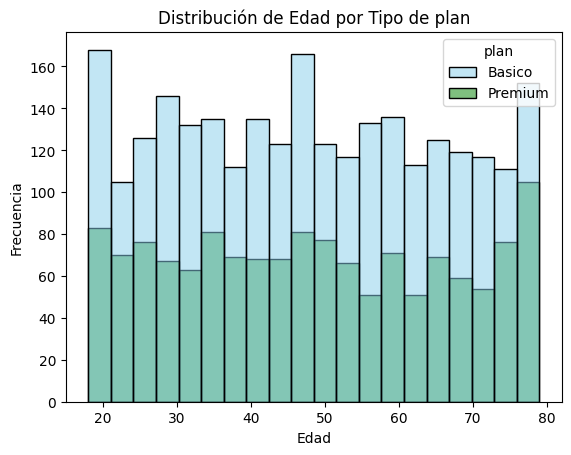

In [ ]:
# Histograma para visualizar la edad (age)
sns.histplot(data= user_profile, x='age', hue='plan', bins= 20, palette=['skyblue','green'])
plt.title('Distribución de Edad por Tipo de plan')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()

💡Insights:
- Distribución de Planes por Edad - ConnectaTel

Hallazgo Principal:
El plan Básico domina en todas las edades, representando aproximadamente el 65% de las contrataciones vs 35% del Premium. Sin embargo, se identifican tres picos significativos de demanda en el plan Básico y un pico en el plan Premium que representan oportunidades estratégicas.

Patrones Identificados:
- Jóvenes (18-23 años): Pico de 160+ usuarios en Básico, posiblemente por limitaciones presupuestarias.
- Adultos medios (45-48 años): Segundo pico de 160+ usuarios en Básico, posiblemente porque quieren un plan simple.
- Adultos mayores (75-78 años): Terser pico de poco más de 140 usuarios en Básico y Único segmento  con mayor cantidad de usuarios con plan Premium (poco más de 100 usuarios), indicando mayor distribución de pago.

Recomendaciones:
1. Desarrollar estrategias de upselling diferenciadas para los tres picos del Básico.
2. Investigar qué motiva a los adultos mayores (75-78) a elegir Premium y replicar esos factores.
3. Considerar planes intermedios o promociones específicas por grupo de edad.

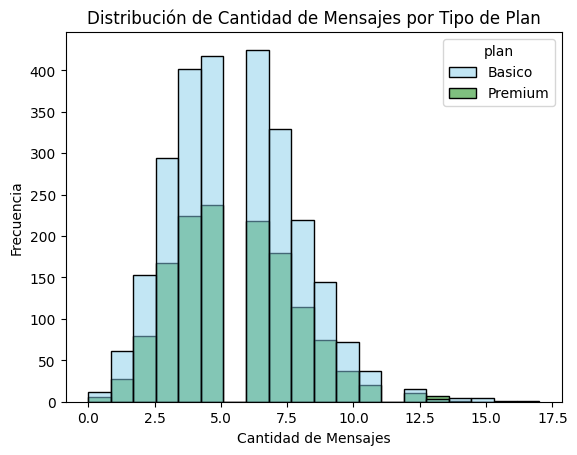

plan
Basico     64.905848
Premium    35.094152
Name: cant_mensajes, dtype: float64


In [ ]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data= user_profile, x='cant_mensajes', hue='plan', bins= 20, palette=['skyblue','green'])
plt.title('Distribución de Cantidad de Mensajes por Tipo de Plan')
plt.xlabel('Cantidad de Mensajes')
plt.ylabel('Frecuencia')
plt.show()
# Total de mensajes por plan
total_por_plan = user_profile.groupby('plan')['cant_mensajes'].sum()
# Porcentaje del total por plan
porcentaje = (total_por_plan / total_por_plan.sum()) * 100
print(porcentaje)

💡Insights:
- Distribución de cantidad de mensajes por tipo de plan -ConnectaTel

Hallazgo principal:
No existe diferencia significativa en el comportamiento de envío de mensajes entre usuarios de plan Básico y Premium.

Patrones identificados:
- Distribución sesgada a la derecha con la mayoría de usuarios enviando 0-11 mensajes.
- Los usuarios Básico generan 64.9% de mensajes vs 35.1% Premium.
- La proporción de mensajes coincide con la distribución de usuarios (64.8% Básico, 35.2% Premium).

Implicación para el negocio:
La cantidad de mensajes no es un diferenciador entre planes, sugiriendo que los usuarios eligen Premium por otros beneficios (más GB, minutos incluidos, etc.) y no por hacer más llamadas.

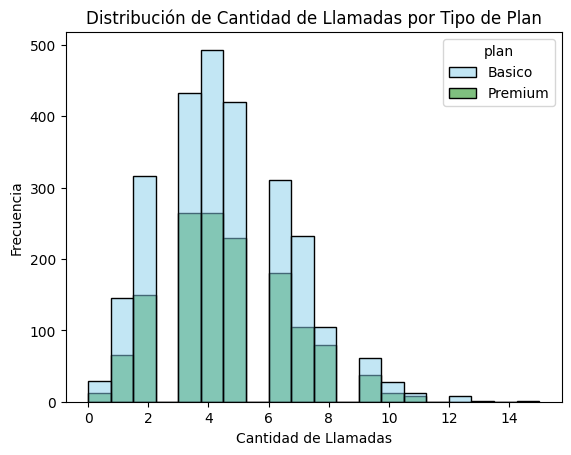

plan
Basico     64.552155
Premium    35.447845
Name: cant_llamadas, dtype: float64


In [ ]:
# Histograma para visualizar la cant_llamadas
sns.histplot(data= user_profile, x='cant_llamadas', hue='plan', bins=20, palette=['skyblue','green'])
plt.title('Distribución de Cantidad de Llamadas por Tipo de Plan')
plt.xlabel('Cantidad de Llamadas')
plt.ylabel('Frecuencia')
plt.show()
# Total de llamadas por plan
total_por_plan = user_profile.groupby('plan')['cant_llamadas'].sum()
# Porcentaje del total por plan
porcentaje = (total_por_plan / total_por_plan.sum()) * 100
print(porcentaje)

💡Insights:
- Distribución de cantidad de llamadas por tipo de plan -ConnectaTel

Hallazgo Principal:
Los usuarios del plan Básico realizan más llamadas en términos absolutos (64.55% del total) vs Premium (35.45%), pero esto refleja principalmente la mayor base de usuarios Básico (64.8%) en lugar de diferencias en el comportamiento de uso.

Patrones Identificados:
- Distribución sesgada a la derecha en ambos planes.
- Concentración de datos entre 0-10 llamadas.
- No hay diferencias significativas en el patrón de uso entre planes.
.
Implicación para el negocio:
La cantidad de llamadas no es un diferenciador entre planes, sugiriendo que los usuarios eligen Premium por otros beneficios (más GB, minutos incluidos, etc.) y no por hacer más llamadas.

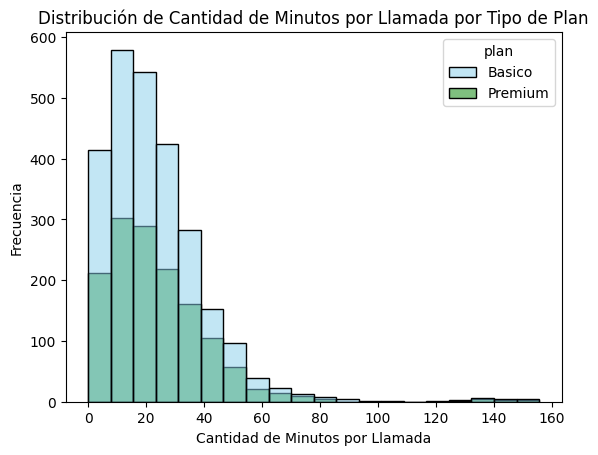

plan
Basico     63.721126
Premium    36.278874
Name: cant_minutos_llamada, dtype: float64


In [ ]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data= user_profile, x='cant_minutos_llamada', hue='plan', bins=20, palette=['skyblue','green'])
plt.title('Distribución de Cantidad de Minutos por Llamada por Tipo de Plan')
plt.xlabel('Cantidad de Minutos por Llamada')
plt.ylabel('Frecuencia')
plt.show()
# Total de minutos por llamada por plan
total_por_plan = user_profile.groupby('plan')['cant_minutos_llamada'].sum()
# Porcentaje del total por plan
porcentaje = (total_por_plan / total_por_plan.sum()) * 100
print(porcentaje)

💡Insights:
- Distribución de Cantidad de Minutos por Llamada por Tipo de Plan -ConnectaTel

Hallazgo Principal:
La distribución de minutos por llamada es proporcional al número de usuarios por plan, distribución de cada plan es: Plan Básico 63.7% de minutos vs 64.8% de usuarios; Premium 36.3% de minutos vs 35.2% de usuarios. No hay diferencias significativas en el comportamiento de llamadas entre planes.

Patrones Identificados:

- Distribución sesgada a la derecha en ambos planes.
- la concentración de la mayor cantidad de minutos por llamada está entre 0-60 minutos.
- Comportamiento similar: Ambos planes muestran patrones de uso comparables.

Implicación para el negocio:
- Los usuarios no cambian significativamente su comportamiento de llamadas al tener un plan premium.
- La estrategia de diferenciación debe enfocarse en otros beneficios (calidad, servicios adicionales) más que en duración de llamadas.
- Los costos operativos por minuto son predecibles y proporcionales a la base de usuarios.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age`
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

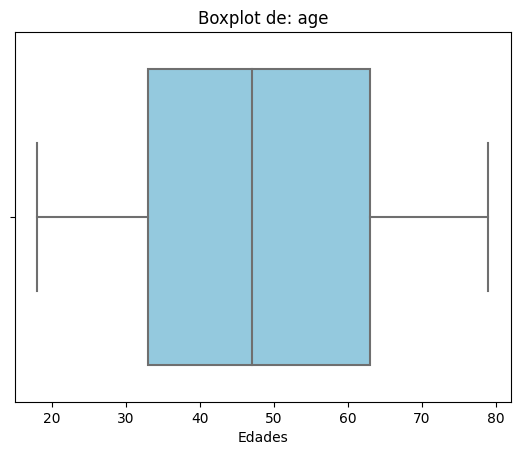

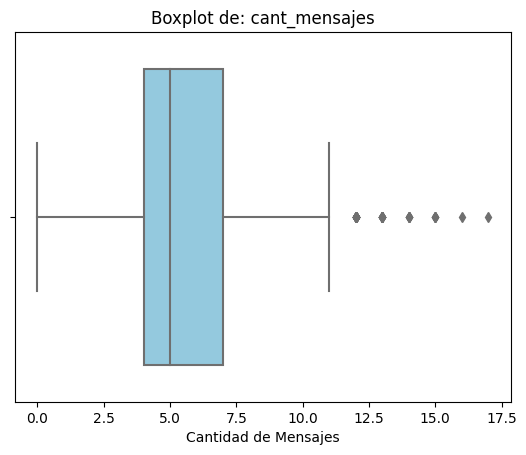

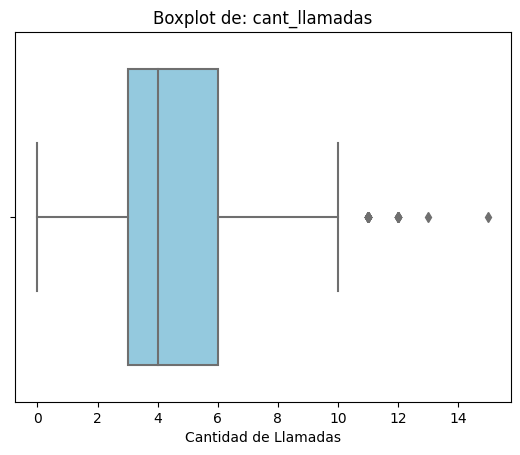

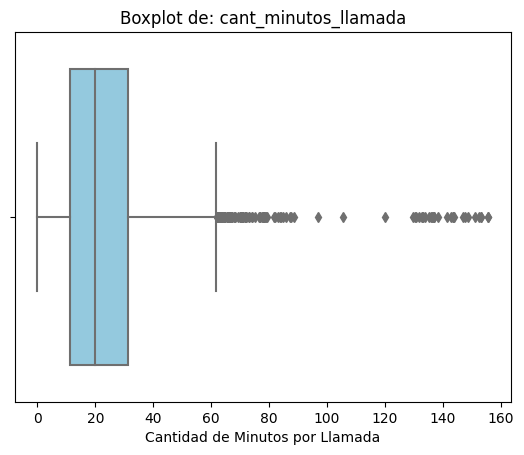

In [ ]:
# Visualizando usando BoxPlot
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    sns.boxplot(x= user_profile[col], color='skyblue')
    if col == 'age':
        plt.xlabel('Edades')
    elif col== 'cant_mensajes':
        plt.xlabel('Cantidad de Mensajes')
    elif col== 'cant_llamadas':
        plt.xlabel('Cantidad de Llamadas')
    elif col== 'cant_minutos_llamada':
        plt.xlabel('Cantidad de Minutos por Llamada')

    plt.title(f'Boxplot de: {col}')
    plt.show()


💡Insights:
**Age: No presenta outliers.**

  **Observación detallada:**
  
  - No se identifican valores extremos en las edades de los usuarios.
  - la edad promedio es aproximadamente 48 años.
  - La distribución de edades muestra un comportamiento concentrados sin disperción extrema.
    
  **Intepretación:**
  
  - ConnectaTel tiene una base de clientes homogénea.
  - Atraen a usuarios en edad productiva y estable económicamente.
  - No hay segmento de edades muy jóvenes o muy mayores representados de forma significativa.
    
  **Implicación de negocio:**
  
  - Indica una base de clientes estable y homogénea.
  -  Oportunidad de desarrollar estrategias específicas para el segmento de personas de edad promedio (48 años).
  -  Potencial para explorar mercados no atendidos (jóvenes (18-30) o adultos mayores (65+)).
    
**cant_mensajes: sí presenta outliers.**

  **Observación detallada:**
  
  - Se identifican usuarios con valores extremos que envían hasta 17 mensajes.
  - La mayoría de los usuarios se concentra en un rango promedio de 5.5 mensajes.
  - Los outliers representan un pequeño porcentaje.
    
  **Interpretación:**
  
  - posiblemente los usuarios que tienen más demanda de envío de mensajes son personas empresariales, comerciales o con planes familiares compartidos.
    
  **Implicación de negocio:**
  
  - Oportunidad de crear planes especializados con mayor cuota de mensajes para estos usuarios.
  - potencial de upselling hacia planes premium que curan mejor sus necesidades.
  - Riesgo de pérdida de estos usuarios valiosos si no se atienden adecuadamente sus necesidades.

**cant_llamadas: Si presenta outliers.**

  **Observación detallada:**
  
  - Se identifican usuarios con valores extremos en la cantidad de llamadas realizadas de hasta 15 llamadas.
  - Los outliers muestran un uso significativamente mayor al patrón normal.
    
  **Interpretación:**
  
  - Estos usuarios probablemente dependen fuertemente de las llamadas para su trabajo o actividades personales
    
  **Implicación de negocio:**
  
  - Oportunidad de desarrollar planes con minutos ilimitados o cuotas altas de llamadas.
  - Riesgo de sobrecosto si estos usuarios exceden regularmente sus planes actuales.

**cant_minutos_llamada: Si presenta outliers.**

  **Observación detallada:**
  
  - Los outlier muestran llamadas con duración muy por encima del promedio típico.
    
  **Interpretación:**
  
  - Existe un segmento de usuarios que realiza llamadas muy extensas, posiblemente por motivos profesionales que requieren conversaciones largas o usuarios  con relaciones            familiares a larga distancia o necesidades especiales de comunicación.
    
  **Implicación de negocio:**
  
  - Oportunidades de crear planes con tarifas preferenciales para llamadas de larga duración.
  - Riesgo a que miren a competidores si no se ofrecen planes adecuados para su patrón de uso   

In [ ]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas','cant_minutos_llamada']

for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)

    IQR = Q3 - Q1

    limite_superior = Q3 +1.5 * IQR

    print(f'\n{col}:')
    print(f'Q1: {Q1}')
    print(f'Q3: {Q3}')
    print(f'IQR: {IQR}')
    print(f'Límite superior: {limite_superior}')
    print(f'valor máximo en datos: {user_profile[col].max()}')





cant_mensajes:
Q1: 4.0
Q3: 7.0
IQR: 3.0
Límite superior: 11.5
valor máximo en datos: 17

cant_llamadas:
Q1: 3.0
Q3: 6.0
IQR: 3.0
Límite superior: 10.5
valor máximo en datos: 15

cant_minutos_llamada:
Q1: 11.12
Q3: 31.415
IQR: 20.295
Límite superior: 61.8575
valor máximo en datos: 155.69


In [ ]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights:
**- cant_mensajes: mantener o no outliers, porqué?**

  Mantener outliers. Los valores extremos son de 12-17 mensajes, representando usuarios con patrones de comunicación realistas.
   Estos outliers son valiosos porque:
   - 17 mensajes por usuario puede ser posible, no es un número tan exorbitante.
   - Este tipo de usuarios podrían ser candidatos para planes premium en caso de que estén en el plan básico.
   - Los valores de IQR y el máximo son moderados, no distorsionarían tanto las métricas.
   - Eliminar estos usuarios sería un error. ya que es información de alto valor en la que se podrían aplicar estrategias comerciales diferentes.
     
**- cant_llamadas: mantener o no outliers, porqué?**

  Mantener outliers. Los valores extremos son de 11-15 llamadas, representando usuarios con alta actividad telefónica realistas.
   Estos outliers son valiosos porque:
   - 15 llamadas por usuario pueden ser posibles, no es un número tan exorbitante.
   - Este tipo de usuarios podrían tener actividades que requieran realizar múltiples llamadas como profesionales de servicio al cliente, consultores, etc.
   - Este tipo de usuarios podrían ser candidatos para planes con más minutos o llamadas ilimitadas.
   - Los valores IQR y el máximo son moderados, no distorsionarían tanto las métricas.
   - Eliminar estos outliers sería un error, ya que es información de alto valor en la que se podrían aplicar estrategias comerciales diferentes.
     
**- cant_minutos_llamada: mantener o no outliers, porqué?**

 Mantener outliers. Los valores extremos son de 62-155.69 minutos por llamada, representando usuarios con alta actividad telefónica realistas.
  Estos outliers son valiosos porque:
  - Llamadas de 2.5 horas son posibles.
  - son usuarios que podrían mantener conversaciones largas con familiares o amigos si en caso de que lo utilicen como uso personal y si es uso profesional podrían ser terapeutas, consultores, personas que brindan servicios extensos, etc.
  - Estos usuarios son ideales para minutos ilimitados para tarifas para llamadas largas.
  - Representan upselling a planes premium que satisfagan sus necesidades en caso de que estén en el plan básico.
  - Eliminar estos outliers sería un error, ya que es información de alto valor en la que se podrían aplicar estrategias comerciales diferentes.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [ ]:
# Crear columna grupo_uso
def grupo_uso(row):
    if (row['cant_llamadas'] < 5) & (row['cant_mensajes'] <5):
        return 'Bajo uso'
    elif (row['cant_llamadas']<10) & (row['cant_mensajes']<10):
        return 'Uso medio'
    else:
        return 'Alto uso'
user_profile['grupo_uso'] = user_profile.apply(grupo_uso, axis=1)


In [ ]:
# verificar cambios
user_profile.head()

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,first_name,last_name,age,city,reg_date,plan,churn_date,grupo_uso
0,10000,7,3,23.70,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,Uso medio
1,10001,5,10,33.18,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,Alto uso
2,10002,5,2,10.74,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,Uso medio
3,10003,11,3,8.99,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,Alto uso
4,10004,4,3,8.01,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [ ]:
# Crear columna grupo_edad
def grupo_edad(row):
    if (row['age']<30):
        return 'Joven'
    elif (row['age']<60):
        return 'Adulto'
    else:
        return 'Adulto Mayor'

user_profile ['grupo_edad'] = user_profile.apply(grupo_edad, axis=1)


In [ ]:
# verificar cambios
user_profile.head()

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,first_name,last_name,age,city,reg_date,plan,churn_date,grupo_uso,grupo_edad
0,10000,7,3,23.70,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,Uso medio,Adulto
1,10001,5,10,33.18,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,Alto uso,Adulto
2,10002,5,2,10.74,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,Uso medio,Adulto
3,10003,11,3,8.99,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,Alto uso,Adulto Mayor
4,10004,4,3,8.01,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

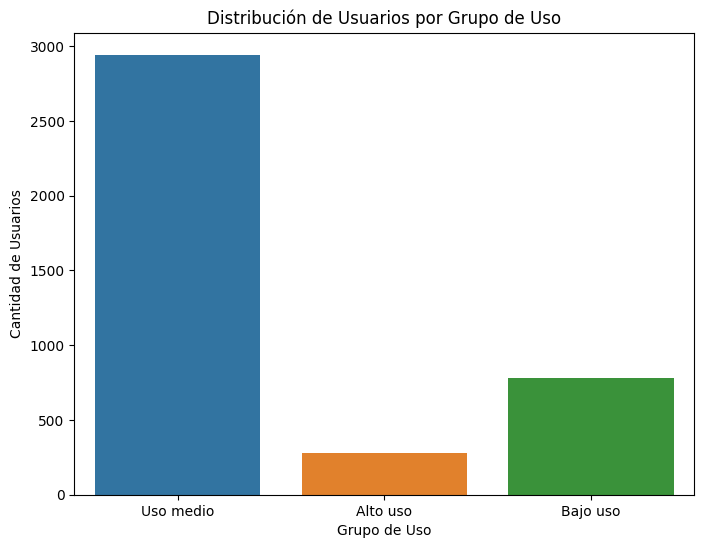

In [ ]:
# Visualización de los segmentos por uso
plt.figure(figsize=(8,6))
sns.countplot(data= user_profile, x='grupo_uso')
plt.title('Distribución de Usuarios por Grupo de Uso')
plt.xlabel('Grupo de Uso')
plt.ylabel('Cantidad de Usuarios')
plt.show()


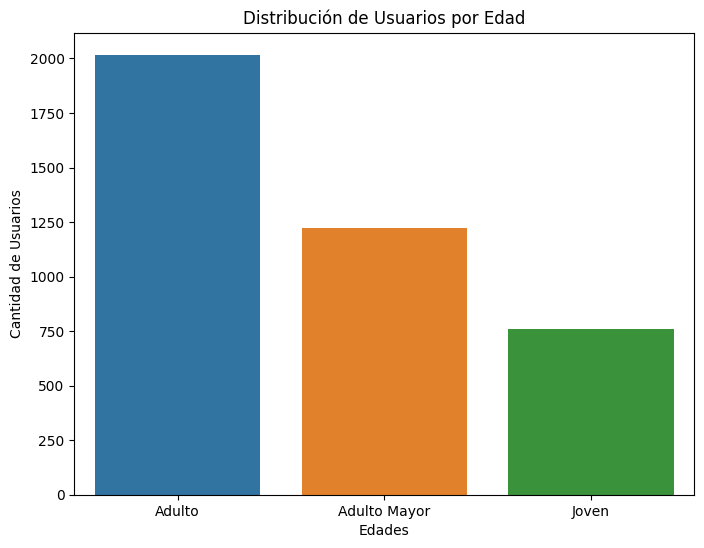

In [ ]:
# Visualización de los segmentos por edad
plt.figure(figsize=(8,6))
sns.countplot(data=user_profile, x='grupo_edad')
plt.title('Distribución de Usuarios por Edad')
plt.xlabel('Edades')
plt.ylabel('Cantidad de Usuarios')
plt.show()



---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:**
- ¿Qué problemas tenían originalmente los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- En el DataSet **users** se detectaron valores nulos en las columnas: 'city' con el 11.7% y 'churn_date' con el 88.3%.
- En el DataSet **usage** se detectaron valores nulos en las columnas: 'date' con el 0.01%, 'duration' con el 55.2% y 'length' con el 44.7%. Se corroboró que son datos MAR porque son nulos al azar.
- En la columna **'age'** se detectaron valores negativos (-999) y se procedió a reemplazarlos con la mediana para que no alteraran demasiado los datos.
- En la columna **'city'** se encontró un sentinel '?' con 96 registros. Fueron reemplazados por valores nulos (NA).
- En la columna **'reg_date'** mostró datos del 2026 y el DataSet debería de tener datos hasta el 2024. Fueron reemplazados por valores nulos (NA).


🔍 **Segmentos por Edad**
- Adultos (30-60): ~2,000 usuarios, el segmento más grande.
- Adultos Mayores (60+): ~1,250 usuarios, únicos con distribución significativa en Premium (~100+ usuarios).
- Jóvenes (18-30): ~750 usuarios, principalmente en plan Básico por posibles limitaciones económicas.


📊 **Segmentos por Nivel de Uso**
- Uso intermedio: ~3,000 usuarios, representa la mayoría del total de usuarios.
- Bajo Uso: ~750 usuarios.
- Alto Uso: ~250 usuarios, el segmento más pequeño.


➡️ Esto sugiere que
- Los adultos mayores representan el segmento de mayor valor, siendo los únicos dispuestos a pagar Premium.
- La mayoría de usuarios (uso intermedio) están satisfechos con un nivel moderado de servicio.
- Existe una oportunidad con los usuarios de alto uso (solo 250), que podrían necesitar un plan especializado.
- Los jóvenes requieren estrategias de precio más accesibles para convertirse en usuarios Premium.

💡 **Recomendaciones**
Para Jóvenes (18-30):
    -Crear posibles descuentos estudiantiles o planes especiales para estudiantes.
    -Ofrecer promociones de entrada para convertirlos gradualmente a Premium.
Para Adultos Mayores (60+):
    - Mantener y potenciar la oferta Premium, ya que muestran disposición de pago.
Crear nuevos planes intermedios:
- Plan "Intermedio" entre Básico y Premium para capturar a usuarios (Uso Intermedio).
- Plan "Pro" para usuarios de alto uso (250 usuarios) que necesitan más funcionalidades.
- Para la mayoría (Uso Intermedio)
Estas recomendaciones permitirían una mejor segmentación en los planes.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`

In [ ]:
# Guardar el dataset procesado con toda tu segmentación
user_profile.to_csv('user_profile_procesado.csv', index=False)

users.to_csv('users_limpio.csv', index=False) #datasets limpios
usage.to_csv('usage_limpio.csv', index=False) #datasets limpios
plans.to_csv('plans.csv', index=False) #datasets limpios

In [ ]:
import shutil
import os

# Copiar archivos originales al directorio actual
archivos_originales = [
    ('/datasets/plans.csv', 'plans_original.csv'),
    ('/datasets/users_latam.csv', 'users_latam_original.csv'),
    ('/datasets/usage.csv', 'usage_original.csv')
]

for origen, destino in archivos_originales:
    if os.path.exists(origen):
        shutil.copy2(origen, destino)
        print(f"✅ Copiado: {destino}")

✅ Copiado: plans_original.csv
✅ Copiado: users_latam_original.csv
✅ Copiado: usage_original.csv
